In [1]:
from pathlib import Path
import sys

# Get the absolute path of the parent directory
parent_dir = str(Path(".").resolve().parent)

# Add it to the system path
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

import pandas as pd
import pydicom as dicom
import os
import re
import matplotlib.pyplot as plt
import numpy as np
import preprocessing
import scipy
import skimage

In [2]:
# path to the root folder of the data
ROOT_FILEPATH = "/run/media/gianluca/EXTERNAL_US/CBIS-DDSM"

# name of manifest folder
MANIFEST_FOLDER = "manifest-ZkhPvrLo5216730872708713142"
MANIFEST_FILEPATH = f"{ROOT_FILEPATH}/{MANIFEST_FOLDER}"

# path to the metadata csv
METADATA_FILEPATH = f"{MANIFEST_FILEPATH}/metadata.csv"

# Metadata cleaning and dataset organization

In [3]:
def parse_subject_metadata(s: str) -> list:
    kind = "Calc" if "Calc" in s else "Mass"
    training = "training" if "Training" in s else "Test"
    direction = "LEFT" if "LEFT" in s else "RIGHT"
    acquisition = "MLO" if "MLO" in s else "CC"

    match = re.search(r'(P_\d+)', s)
    subject_id = match.group(1)

    return [kind, training, subject_id, direction, acquisition]

def get_roi_filename_from_folder(folder_path: str)-> str:
    path = Path(folder_path)
    files = [f.name for f in path.iterdir() if f.is_file()]

    for filename in files:
        dicom_file = dicom.dcmread(f"{folder_path}/{filename}", stop_before_pixels=True)

        if "SeriesDescription" not in dicom_file or ("SeriesDescription" in dicom_file and dicom_file["SeriesDescription"].value != "cropped images"):
            return filename

def to_keep(row):
    fullimage_size = (
        dicom.dcmread(f"{ROOT_FILEPATH}/" + row["fullimage filepath"],stop_before_pixels=True).Rows,
        dicom.dcmread(f"{ROOT_FILEPATH}/" + row["fullimage filepath"],stop_before_pixels=True).Columns
    )

    mask_size = (
        dicom.dcmread(f"{ROOT_FILEPATH}/" + row["roi filepath"],stop_before_pixels=True).Rows,
        dicom.dcmread(f"{ROOT_FILEPATH}/" + row["roi filepath"],stop_before_pixels=True).Columns
    )

    if fullimage_size == mask_size:
        return True
    else:
        return False
    

In [4]:
metadata_df = pd.read_csv(METADATA_FILEPATH)

# getting all the fullimages filepaths
fullimages_df = pd.DataFrame(
    [ 
        parse_subject_metadata(row["Subject ID"]) + [MANIFEST_FOLDER + row["File Location"][1:] + "/1-1.dcm"]
        for _, row in metadata_df[metadata_df["Series Description"] == "full mammogram images"].iterrows()
    ],
    columns = ["kind", "training or test", "Subject ID", "breast", "image view", "fullimage filepath"]
)

# getting all the ROIs
rois = []  
for _, row in metadata_df[metadata_df["Series Description"] == "ROI mask images"].iterrows():
    subject_metadata = parse_subject_metadata(row["Subject ID"])
    folder_path = MANIFEST_FOLDER + row["File Location"][1:]
    roi_filename = get_roi_filename_from_folder(f"{ROOT_FILEPATH}/" + folder_path)
    
    rois.append(subject_metadata + [f"{folder_path}/{roi_filename}"])

# getting all the ROIs
rois_df = pd.DataFrame(
    rois,
    columns = ["kind", "training or test", "Subject ID", "breast", "image view", "roi filepath"]
)

# joining the two dataframes
joined_df = pd.merge(
    left=fullimages_df, 
    right=rois_df,
    how='left',
    left_on=["kind", "training or test", "Subject ID", "breast", "image view"],
    right_on=["kind", "training or test", "Subject ID", "breast", "image view"],
)

# dropna
joined_df = joined_df.dropna(subset = ["fullimage filepath", "roi filepath"])

# drop the entries where the mask doesn't fully match the mammography
joined_df = joined_df[joined_df.apply(to_keep, axis=1)]

# export the final dataset
joined_df.to_csv(f"{ROOT_FILEPATH}/lesions.csv", index=False)

## Testing that Full image and ROI have correspondence

In [ ]:
joined_df = pd.read_csv(f"{ROOT_FILEPATH}/lesions.csv")

for _, row in joined_df.iterrows():
    subject_id = row["Subject ID"]
    breast = row["breast"]
    view = row["image view"]
    kind = row["kind"]
    
    try:
        fullimage_size = (
            dicom.dcmread(f"{ROOT_FILEPATH}/" + row["fullimage filepath"],stop_before_pixels=True).Rows,
            dicom.dcmread(f"{ROOT_FILEPATH}/" + row["fullimage filepath"],stop_before_pixels=True).Columns
        )
    
        mask_size = (
            dicom.dcmread(f"{ROOT_FILEPATH}/" + row["roi filepath"],stop_before_pixels=True).Rows,
            dicom.dcmread(f"{ROOT_FILEPATH}/" + row["roi filepath"],stop_before_pixels=True).Columns
        )
    except Exception as e:
        print(f"Exception on pateint {subject_id} - {breast} - {view} - {kind}: {e}")

    if fullimage_size != mask_size:
        print(f"{subject_id} - {breast} - {view} - {kind}")

## Visualizing some of the lesions

In [7]:
joined_df = pd.read_csv(f"{ROOT_FILEPATH}/lesions.csv")

### P_00038 - LEFT CC

P_00038 - LEFT CC
FULLIMAGE: /run/media/gianluca/EXTERNAL_US/CBIS-DDSM/manifest-ZkhPvrLo5216730872708713142/CBIS-DDSM/Calc-Test_P_00038_LEFT_CC/08-29-2017-DDSM-NA-96009/1.000000-full mammogram images-63992/1-1.dcm

ROI: /run/media/gianluca/EXTERNAL_US/CBIS-DDSM/manifest-ZkhPvrLo5216730872708713142/CBIS-DDSM/Calc-Test_P_00038_LEFT_CC_1/08-29-2017-DDSM-NA-94942/1.000000-ROI mask images-18515/1-2.dcm


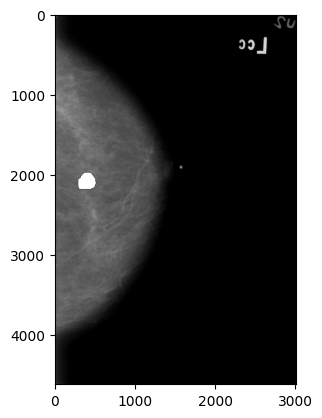

In [9]:
i = 0
subject_id = joined_df.iloc()[i]["Subject ID"]
breast = joined_df.iloc()[i]["breast"]
image_view = joined_df.iloc()[i]["image view"]
fullimage_filepath = joined_df.iloc()[i]["fullimage filepath"]
roi_mask_filepath = joined_df.iloc()[i]["roi filepath"]

array = dicom.dcmread(f"{ROOT_FILEPATH}/{fullimage_filepath}").pixel_array
roi = dicom.dcmread(f"{ROOT_FILEPATH}/{roi_mask_filepath}").pixel_array

print(f"{subject_id} - {breast} {image_view}")
print(f"FULLIMAGE: {ROOT_FILEPATH}/{fullimage_filepath}")
print()
print(f"ROI: {ROOT_FILEPATH}/{roi_mask_filepath}")
plt.imshow(array, cmap=plt.cm.grey)
plt.imshow(roi, cmap=plt.cm.grey, alpha =(roi>0).astype(float))

### P_00038 - LEFT MLO

P_00038 - LEFT MLO
FULLIMAGE: manifest-ZkhPvrLo5216730872708713142/CBIS-DDSM/Calc-Test_P_00038_LEFT_MLO/08-29-2017-DDSM-NA-17613/1.000000-full mammogram images-97934/1-1.dcm

ROI: manifest-ZkhPvrLo5216730872708713142/CBIS-DDSM/Calc-Test_P_00038_LEFT_MLO_1/08-29-2017-DDSM-NA-11739/1.000000-ROI mask images-88680/1-2.dcm


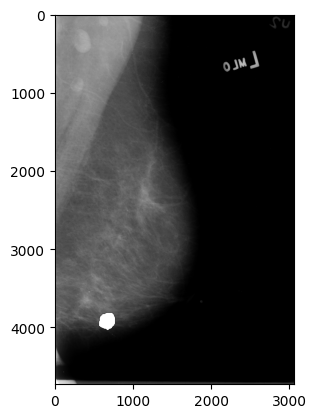

In [10]:
i = 1
subject_id = joined_df.iloc()[i]["Subject ID"]
breast = joined_df.iloc()[i]["breast"]
image_view = joined_df.iloc()[i]["image view"]
#cropped_image_filepath = parsed_df.iloc()[i]["cropped image filepath"]
fullimage_filepath = joined_df.iloc()[i]["fullimage filepath"]
roi_mask_filepath = joined_df.iloc()[i]["roi filepath"]

array = dicom.dcmread(f"{ROOT_FILEPATH}/{fullimage_filepath}").pixel_array
roi = dicom.dcmread(f"{ROOT_FILEPATH}/{roi_mask_filepath}").pixel_array

print(f"{subject_id} - {breast} {image_view}")
print(f"FULLIMAGE: {fullimage_filepath}")
print()
print(f"ROI: {roi_mask_filepath}")
plt.imshow(array, cmap=plt.cm.grey)
plt.imshow(roi, cmap=plt.cm.grey, alpha =(roi>0).astype(float))

### P_00038 - RIGHT CC

P_00038 - RIGHT CC
FULLIMAGE: manifest-ZkhPvrLo5216730872708713142/CBIS-DDSM/Calc-Test_P_00038_RIGHT_CC/08-29-2017-DDSM-NA-28468/1.000000-full mammogram images-63304/1-1.dcm

ROI: manifest-ZkhPvrLo5216730872708713142/CBIS-DDSM/Calc-Test_P_00038_RIGHT_CC_1/08-29-2017-DDSM-NA-83105/1.000000-ROI mask images-37851/1-2.dcm


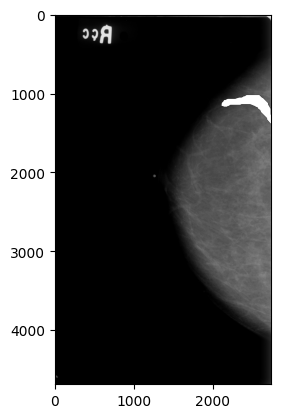

In [11]:
i = 2
subject_id = joined_df.iloc()[i]["Subject ID"]
breast = joined_df.iloc()[i]["breast"]
image_view = joined_df.iloc()[i]["image view"]
fullimage_filepath = joined_df.iloc()[i]["fullimage filepath"]
roi_mask_filepath = joined_df.iloc()[i]["roi filepath"]

array = dicom.dcmread(f"{ROOT_FILEPATH}/{fullimage_filepath}").pixel_array
roi = dicom.dcmread(f"{ROOT_FILEPATH}/{roi_mask_filepath}").pixel_array

print(f"{subject_id} - {breast} {image_view}")
print(f"FULLIMAGE: {fullimage_filepath}")
print()
print(f"ROI: {roi_mask_filepath}")
plt.imshow(array, cmap=plt.cm.grey)
plt.imshow(roi, cmap=plt.cm.grey, alpha =(roi>0).astype(float))

P_00038 - RIGHT CC
FULLIMAGE: manifest-ZkhPvrLo5216730872708713142/CBIS-DDSM/Calc-Test_P_00038_RIGHT_CC/08-29-2017-DDSM-NA-28468/1.000000-full mammogram images-63304/1-1.dcm

ROI: manifest-ZkhPvrLo5216730872708713142/CBIS-DDSM/Calc-Test_P_00038_RIGHT_CC_2/08-29-2017-DDSM-NA-67143/1.000000-ROI mask images-07570/1-2.dcm


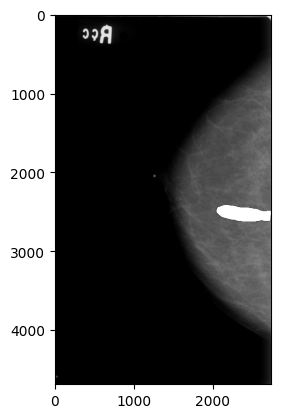

In [12]:
i = 3
subject_id = joined_df.iloc()[i]["Subject ID"]
breast = joined_df.iloc()[i]["breast"]
image_view = joined_df.iloc()[i]["image view"]
fullimage_filepath = joined_df.iloc()[i]["fullimage filepath"]
roi_mask_filepath = joined_df.iloc()[i]["roi filepath"]

array = dicom.dcmread(f"{ROOT_FILEPATH}/{fullimage_filepath}").pixel_array
roi = dicom.dcmread(f"{ROOT_FILEPATH}/{roi_mask_filepath}").pixel_array

print(f"{subject_id} - {breast} {image_view}")
print(f"FULLIMAGE: {fullimage_filepath}")
print()
print(f"ROI: {roi_mask_filepath}")
plt.imshow(array, cmap=plt.cm.grey)
plt.imshow(roi, cmap=plt.cm.grey, alpha =(roi>0).astype(float))

# Preprocessing

## Visualization of preprocessing steps

/run/media/gianluca/EXTERNAL_US/CBIS-DDSM/manifest-ZkhPvrLo5216730872708713142/CBIS-DDSM/Calc-Test_P_00038_LEFT_CC/08-29-2017-DDSM-NA-96009/1.000000-full mammogram images-63992/1-1.dcm


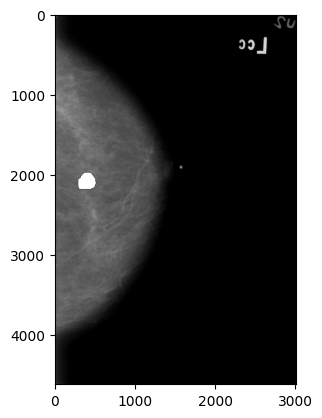

In [4]:
lesions_df = pd.read_csv(f"{ROOT_FILEPATH}/lesions.csv")

# histogram equalization
i = 0
subject_id = lesions_df.iloc()[i]["Subject ID"]
breast = lesions_df.iloc()[i]["breast"]
image_view = lesions_df.iloc()[i]["image view"]
fullimage_filepath = f"{ROOT_FILEPATH}/" + lesions_df.iloc()[i]["fullimage filepath"]
roi_mask_filepath = f"{ROOT_FILEPATH}/" + lesions_df.iloc()[i]["roi filepath"]

array = dicom.dcmread(fullimage_filepath).pixel_array
roi = dicom.dcmread(roi_mask_filepath).pixel_array

print(fullimage_filepath)
plt.imshow(array, cmap=plt.cm.grey)
plt.imshow(roi, cmap=plt.cm.grey, alpha =(roi>0).astype(float))

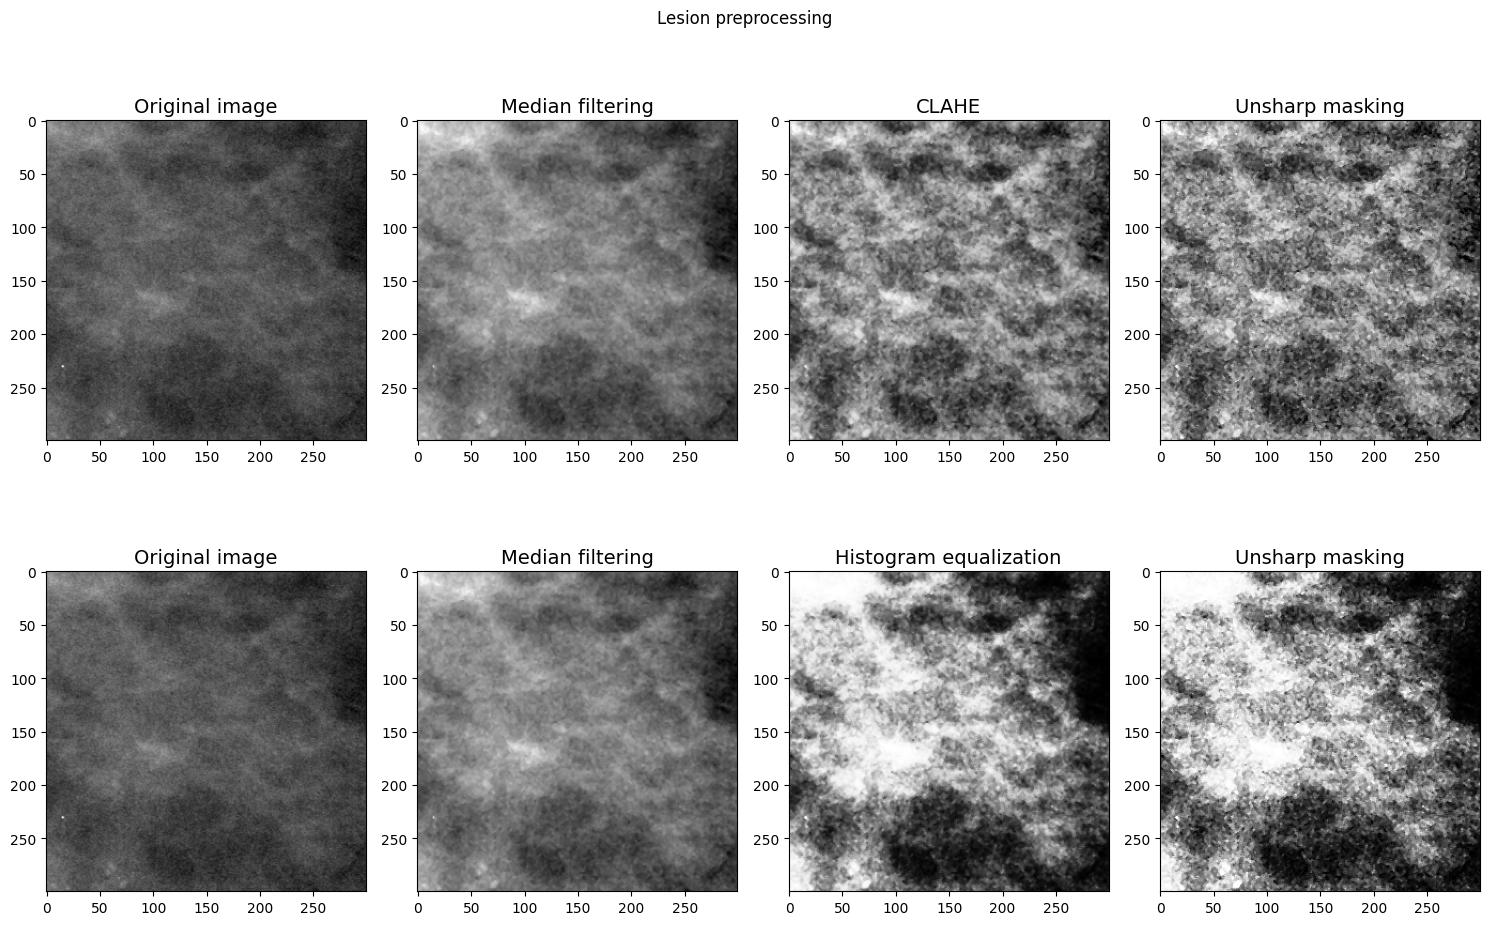

In [6]:
resized_array = array[1600:1900,350:650]

fig, ax = plt.subplots(2, 4, figsize=(15,10))
fig.suptitle('Lesion preprocessing')
ax[0,0].imshow(resized_array, cmap=plt.cm.grey)
ax[1,0].imshow(resized_array, cmap=plt.cm.grey)

# median filtering
median_filtered_array = scipy.ndimage.median_filter(resized_array, size=3)
ax[0,1].imshow(median_filtered_array, cmap=plt.cm.grey)
ax[1,1].imshow(median_filtered_array, cmap=plt.cm.grey)

# clahe and un sharp masking
clahe_array = skimage.exposure.equalize_adapthist(median_filtered_array)

ax[0,2].imshow(clahe_array, cmap=plt.cm.grey)
ax[0,3].imshow(skimage.filters.unsharp_mask(clahe_array), cmap=plt.cm.grey)

# histogram equalization and un sharp masking
equalized_hist_array = skimage.exposure.equalize_hist(median_filtered_array)
ax[1,2].imshow(equalized_hist_array, cmap=plt.cm.grey)
ax[1,3].imshow(skimage.filters.unsharp_mask(equalized_hist_array), cmap=plt.cm.grey)

ax[0,0].set_title('Original image', fontsize=14)
ax[0,1].set_title('Median filtering', fontsize=14)
ax[0,2].set_title('CLAHE', fontsize=14)
ax[0,3].set_title('Unsharp masking', fontsize=14)

ax[1,0].set_title('Original image', fontsize=14)
ax[1,1].set_title('Median filtering', fontsize=14)
ax[1,2].set_title('Histogram equalization', fontsize=14)
ax[1,3].set_title('Unsharp masking', fontsize=14)

fig.tight_layout()
plt.show()

## Visualization of ROI crop

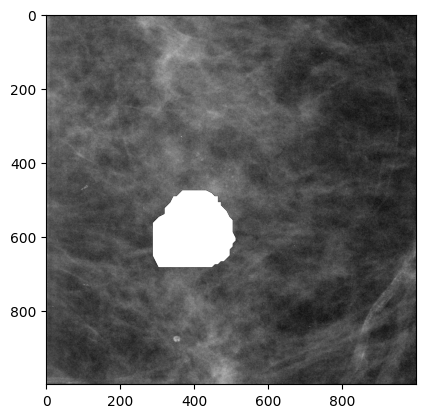

In [25]:
plt.imshow(array[1500:2500,0:1000], cmap=plt.cm.grey)
plt.imshow(roi[1500:2500,0:1000], cmap=plt.cm.grey, alpha =(roi[1500:2500,0:1000]>0).astype(float))

## Application of preprocessing on the whole dataset

In [ ]:
lesions_df = pd.read_csv(f"{ROOT_FILEPATH}/lesions.csv")
lesions_df = preprocessing.preprocess_dataset(lesions_df, ROOT_FILEPATH)
lesions_df.to_csv(f"{ROOT_FILEPATH}/lesions.csv", index=False)